# **Mestrado em Informática**
# **Pós-Graduação em Data Science and Digital Transformation**

## *Análise de Dados e Aprendizagem Automática*

**Mónica Vieira Martins**  
----
># Tutorial 7 - Máquinas de Suporte Vetorial. Optimização



Neste tutorial usa-se o conjunto de dados referentes ao naufrágio do Titanic trabalhado nos tutoriais anteriores para construir, treinar, e testar modelos de Máquinas de Suporte Vetorial, com enfoque no efeito dos parâmetros (kernel, regularização e gama). É ainda usada a ferramenta GridSearchCV para optimização dos hiperparâmetos do modelo.

# Dados  e pré-processamento

In [1]:
%pip install mlxtend

Note: you may need to restart the kernel to use updated packages.


In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix


In [3]:
# Load the data de traino e de teste
train = pd.read_csv("datasets/titanic_train.csv", sep=',')
test = pd.read_csv("datasets/titanic_test.csv", sep=',')

In [4]:
train.head()

,Pclass,Age,Fare,FamilySize,Sex,Embarked_1,Embarked_0,Survived
0,3.0,29.745184,15.2458,2.0,0.0,0.0,0.0,0
1,2.0,31.000000,10.5000,0.0,1.0,0.0,1.0,0
2,2.0,31.000000,37.0042,2.0,1.0,0.0,0.0,0
3,3.0,20.000000,4.0125,0.0,1.0,0.0,0.0,0
4,3.0,21.000000,7.2500,0.0,1.0,0.0,1.0,0


In [5]:
test.head()

,Pclass,Age,Fare,FamilySize,Sex,Embarked_1,Embarked_0,Survived
0,3.0,29.745184,14.4583,0.0,1.0,0.0,0.0,0
1,3.0,29.745184,7.5500,0.0,1.0,0.0,1.0,0
2,3.0,7.000000,29.1250,5.0,1.0,1.0,0.0,0
3,1.0,29.745184,146.5208,1.0,0.0,0.0,0.0,1
4,3.0,29.000000,15.2458,2.0,0.0,0.0,0.0,1


In [6]:
print(train.shape)
print(test.shape)

(712, 8)
(179, 8)


In [7]:
#Criar as variáveis de treino e teste
ytrain = train.Survived
ytest = test.Survived

In [8]:
Xtrain = train.drop("Survived", axis=1)
Xtest = test.drop("Survived", axis=1)

Uma vez que os algoritmos SVM implicam o cálculo de distâncias, vamos padronizar os dados, à semelhança do que foi feito no tutorial anterior.  
 Usamos o `RobustScaler`



In [9]:
from sklearn.preprocessing import RobustScaler
RScaler = RobustScaler()
Xtrain_RScl= pd.DataFrame(
    RScaler.fit_transform(Xtrain),
    columns = Xtrain.columns,
    index = Xtrain.index)
Xtest_RScl = pd.DataFrame(
    RScaler.fit_transform(Xtest),
    columns = Xtest.columns,
    index = Xtest.index)

## Definição de Funções

Função para impressão do gráfico da matriz de confusão e do relatório de classificação

In [10]:
#Data frame para registo de performance
performance = pd.DataFrame(columns=['Train Accuracy','Test Accuracy', "Test f1"])

In [11]:
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.metrics import f1_score, accuracy_score
rotulos=["Não sobreviveu", "Sobreviveu"]

def model_evaluation(acc_train, verdadeiros, previstos,  titulo):
  ''' Função que cria e imprime a
    matriz de confusão de um dados modelo e respetivo relatório de classificação
    preenche o df calssification report
    verdadeitos - rotulos evrdadeiros do conjunto de teste
    previstos - rotulos previstos pelo modelo no conjunto de teste
    acc_train - exatidão do modelo no conjunto de treino, calculada previamente
    titulo - nome do modelo
  '''
  conf_matrix =  confusion_matrix(verdadeiros, previstos,  normalize="true")
  s = sns.heatmap(conf_matrix, annot=True, cmap="Greens",
              xticklabels=rotulos, yticklabels=rotulos)
  s.set(xlabel = "Rótulo Previsto", ylabel="Rótulo Verdadeiro", title=titulo)
  plt.show()
  print(classification_report(verdadeiros, previstos))
  #preencher DF com resumo da performance
  #Avaliar o modelo com a exatidão


  acc_test= accuracy_score(verdadeiros, previstos)
  f1 = f1_score(verdadeiros, previstos, average="macro" )

  performance.loc[titulo,
                  ['Train Accuracy','Test Accuracy', "Test f1"]] =[
                  '{0:.2f}'.format(acc_train),
                  '{0:.2f}'.format(acc_test),
                 '{0:.2f}'.format(f1)]



# SVM com diferentes funções kernel

Em `scikit learn` os modelos de classificação com  SVM podem ser treinados usando a classe  `svm.SVC`. Aqui, SVC é o acrónimo de "Support Vector Classification".
A documentação da classe  pode ser consultada aqui:
https://scikit-learn.org/stable/modules/generated/sklearn.svm.SVC.html#sklearn.svm.SVC

O construtor da classe possui vários parâmetros, do quais os mais importantes são a **função *kernel*** usada,  o **parâmetro C** e o **parâmetro gama**.
* **função *kernel*** : função que é usada para definir a fronteira entre as classes;
* **parâmetro C** : parâmetro de regularização;  
* **parâmetro gama** (sigma): controla quais pontos são considerados vetores de suporte com base na sua distância ao hiperplano.



Relativamente às **funções kernel**, a implementação de `sklearn` permite utilizar
*  a função linear (sem kernel) : quando a separação dos dados é linear;
*  função gausseana (`rbf - radial basis function`): quando a separação dos pontos segue uma distribuição normal;
*  funções polinomiais de grau variável: quando a separação dos dados segue uma distribuição polinomial (de diferentes graus);
*  função sigmóide

Relativamente ao **parâmetro C**, importa reter que  valores baixos de C correspondem a maior regularização.   
Valores baixos de C farão com que o modelo tente ajustar-se à maioria dos pontos; implica menor variância
valores mais elevados de C realçam a importância de cada ponto individual ser classificado corretamente; implica maior variância.



Vamos começar por treinar um modelo SVM com a  função gausseana, `kernel="rbf"`. Para todos os restantes argumentos serão usados os valores por defeito.

O processo é o mesmo a que já estamos habituados:  
* criar o modelo;
* treinar o modelo com Xtrain e ytrain.
* obter as previsões, com Xtest
* determinar as métricas de performance do modelo


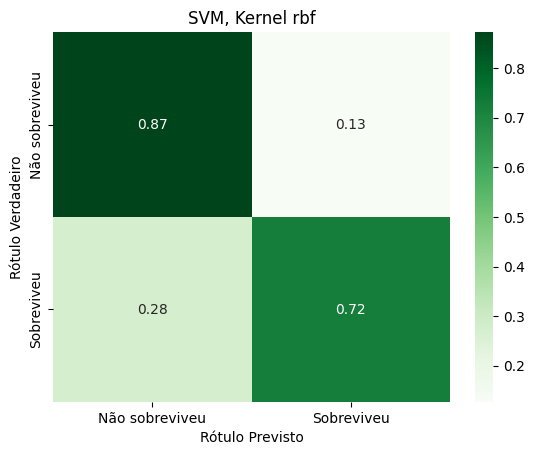

              precision    recall  f1-score   support

           0       0.83      0.87      0.85       110
           1       0.78      0.72      0.75        69

    accuracy                           0.82       179
   macro avg       0.81      0.80      0.80       179
weighted avg       0.81      0.82      0.81       179



,Train Accuracy,Test Accuracy,Test f1
"SVM, Kernel rbf",0.83,0.82,0.80


In [12]:
#Treinar e testar o modelo SVM com kernel gauseana
from sklearn.svm import SVC

svm_rbf = SVC(kernel='rbf')
svm_rbf.fit(Xtrain_RScl, ytrain)
ypred = svm_rbf.predict(Xtest_RScl)
acc_train = svm_rbf.score(Xtrain_RScl, ytrain)
model_evaluation(acc_train, ytest, ypred, "SVM, Kernel rbf")
display(performance)

Agora podemos testar outras funções:

a linear , a polinomial de grau 2, polinomial de grau 3, sigmoid

SVM, kernel linear


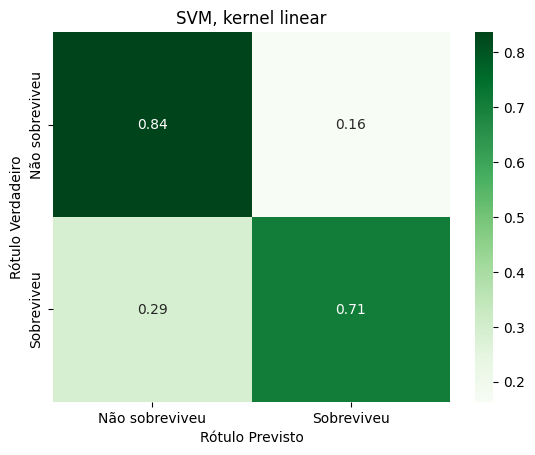

              precision    recall  f1-score   support

           0       0.82      0.84      0.83       110
           1       0.73      0.71      0.72        69

    accuracy                           0.79       179
   macro avg       0.78      0.77      0.77       179
weighted avg       0.79      0.79      0.79       179

SVM, kernel poly, grau 2


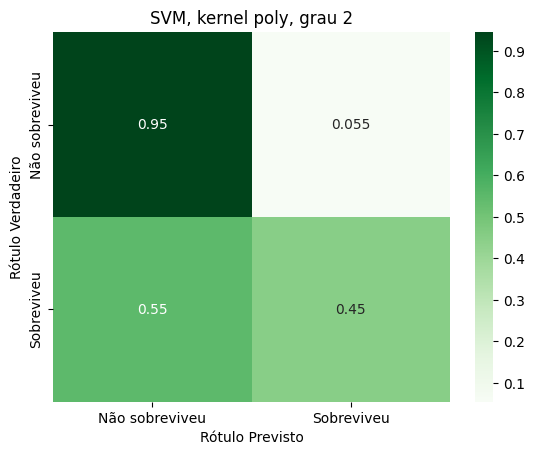

              precision    recall  f1-score   support

           0       0.73      0.95      0.83       110
           1       0.84      0.45      0.58        69

    accuracy                           0.75       179
   macro avg       0.79      0.70      0.71       179
weighted avg       0.77      0.75      0.73       179

SVM, kernel poly, grau 3


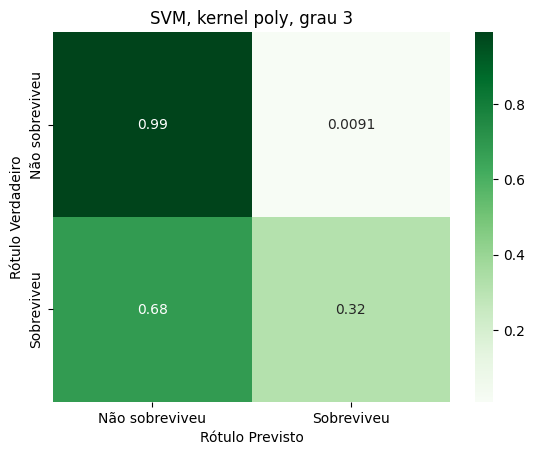

              precision    recall  f1-score   support

           0       0.70      0.99      0.82       110
           1       0.96      0.32      0.48        69

    accuracy                           0.73       179
   macro avg       0.83      0.65      0.65       179
weighted avg       0.80      0.73      0.69       179

SVM, kernel rbf


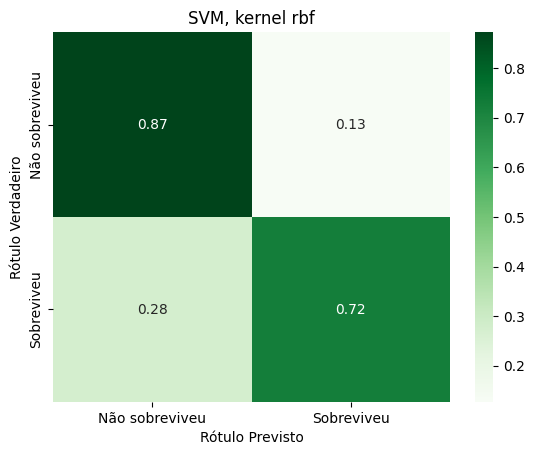

              precision    recall  f1-score   support

           0       0.83      0.87      0.85       110
           1       0.78      0.72      0.75        69

    accuracy                           0.82       179
   macro avg       0.81      0.80      0.80       179
weighted avg       0.81      0.82      0.81       179

SVM, kernel sigmoid


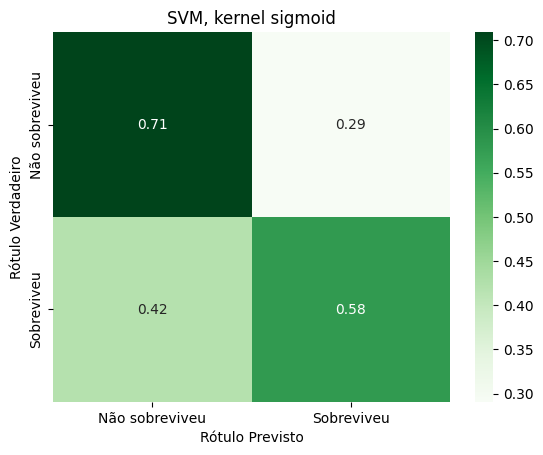

              precision    recall  f1-score   support

           0       0.73      0.71      0.72       110
           1       0.56      0.58      0.57        69

    accuracy                           0.66       179
   macro avg       0.64      0.64      0.64       179
weighted avg       0.66      0.66      0.66       179



,Train Accuracy,Test Accuracy,Test f1
"SVM, Kernel rbf",0.83,0.82,0.80
"SVM, kernel linear",0.79,0.79,0.77
"SVM, kernel poly, grau 2",0.82,0.75,0.71
"SVM, kernel poly, grau 3",0.77,0.73,0.65
"SVM, kernel rbf",0.83,0.82,0.80
"SVM, kernel sigmoid",0.66,0.66,0.64


In [13]:
kernel =['linear', 'poly', 'rbf', 'sigmoid']
for k in kernel:
  if  k == 'poly':
    for i in range(2, 4): #testar polinomial com grau 2 e 3
      nome = f"SVM, kernel {k}, grau {i}"
      print(nome)
      svm = SVC(kernel = k, degree=i)
      svm.fit(Xtrain_RScl, ytrain)
      ypred_test=svm.predict(Xtest_RScl)
      acc_score=svm.score(Xtrain_RScl, ytrain)
      model_evaluation(acc_score, ytest, ypred_test, nome)
  else:
      nome = f"SVM, kernel {k}"
      print(nome)
      svm = SVC(kernel = k)
      svm.fit(Xtrain_RScl, ytrain)
      ypred_test=svm.predict(Xtest_RScl)
      acc_score=svm.score(Xtrain_RScl, ytrain)
      model_evaluation(acc_score, ytest, ypred_test, nome)

display(performance)


In [14]:
#ordenar o df performance por melhor f1titulo
performance = performance.sort_values(by="Test f1", ascending=False)
display(performance)

,Train Accuracy,Test Accuracy,Test f1
"SVM, Kernel rbf",0.83,0.82,0.80
"SVM, kernel rbf",0.83,0.82,0.80
"SVM, kernel linear",0.79,0.79,0.77
"SVM, kernel poly, grau 2",0.82,0.75,0.71
"SVM, kernel poly, grau 3",0.77,0.73,0.65
"SVM, kernel sigmoid",0.66,0.66,0.64


### Visualização das regiões de decisão

Em seguida, a título exemplificativo, criam-se os plots das regiões de classificação para os kernel usados.

As visualizações serão feitas em grágicos 2D, pelo que se torna necessário criar modelos usando apenas 2 features (aqui, `PClass` e `Age`).

Reforça-se que este exercício é apenas exemplificativo, e pretende  reforçar,  através da visuaização, que diferentes funções kernel dão origem a diferentes regiões de decisão.  

In [15]:
Xtrain_RScl.Pclass.value_counts()

Pclass
 0.0    396
-2.0    170
-1.0    146
Name: count, dtype: int64

In [16]:
retirar= ["Sex", "Fare", "FamilySize", "Embarked_1", "Embarked_0"]
Xtrain_red = Xtrain_RScl.drop( retirar, axis=1)
Xtest_red = Xtest_RScl.drop(retirar, axis=1)
Xtrain_red.head()

,Pclass,Age
0,0.0,0.000000
1,-1.0,0.096524
2,-1.0,0.096524
3,0.0,-0.749630
4,0.0,-0.672706


In [17]:
# machine learning extension plotting library : para visualizar as regiões de fronteira.
from mlxtend.plotting import plot_decision_regions
#visualização das regiões de decisão
def decision_bound(Xtrain, ytrain, classifier, Title):
  plt.figure(figsize=(10,5))
  plot_decision_regions(Xtrain.to_numpy(), ytrain.to_numpy(), clf=classifier, legend=2)
  plt.xlabel('PClass')
  plt.ylabel('Age')
  plt.title(Title)
  plt.show()

/home/deck/Mestrado/ContainerHomes/ComputacaoCienciaDados/dev/.venv/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but SVC was fitted with feature names
  warnings.warn(


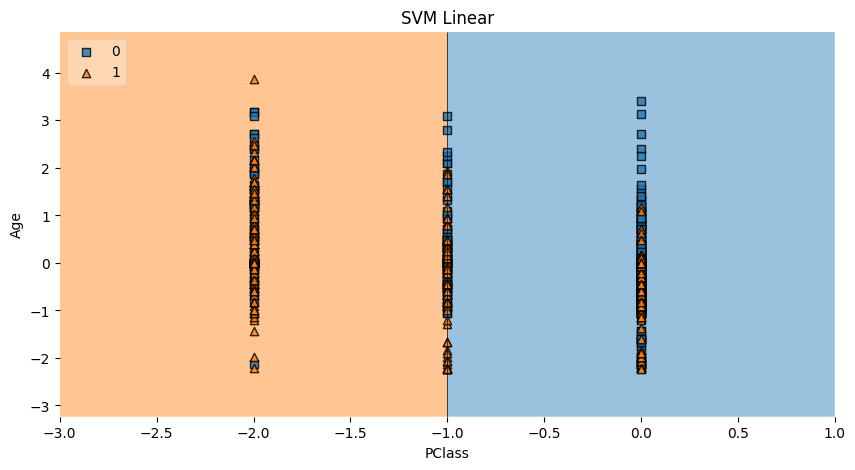

In [18]:
#linear
Titulo = "SVM Linear"
svm = SVC(kernel = 'linear')
svm.fit(Xtrain_red, ytrain)
decision_bound(Xtrain_red, ytrain, svm, Titulo)

Repare-se como as duas regiões de classificação do modelo SVM linear (que corresponde ao algoritmo SVM original, sem função kernel) possuem uma separação absolutamente linear, ao contrário do que se obterá nos exemplos seguintes, em que as funções kernel não são lineares.

/home/deck/Mestrado/ContainerHomes/ComputacaoCienciaDados/dev/.venv/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but SVC was fitted with feature names
  warnings.warn(


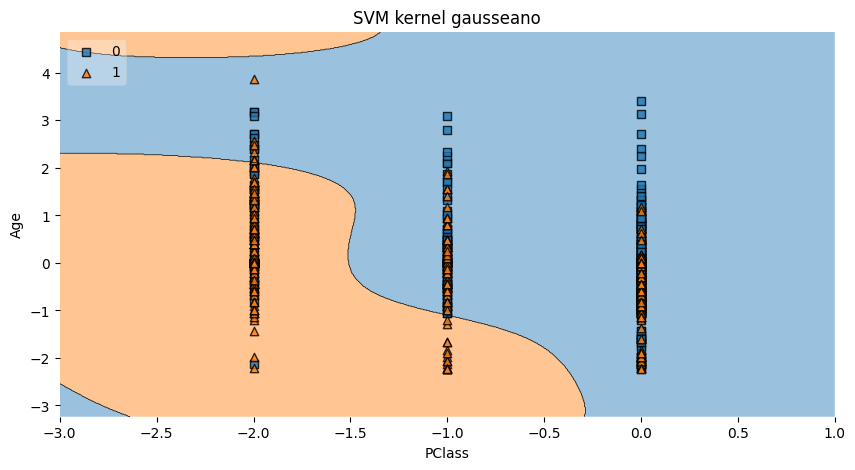

In [19]:
#kernel gausseano
svm_rbf = SVC(kernel = 'rbf')
svm_rbf.fit(Xtrain_red, ytrain)
decision_bound(Xtrain_red, ytrain, svm_rbf, "SVM kernel gausseano")

/home/deck/Mestrado/ContainerHomes/ComputacaoCienciaDados/dev/.venv/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but SVC was fitted with feature names
  warnings.warn(


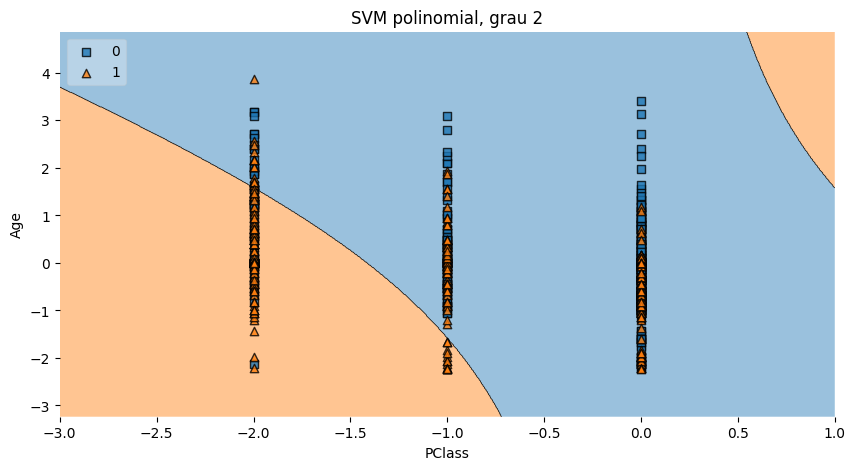

In [20]:
#polinomial grau 2
titulo = "SVM polinomial, grau 2"
svm = SVC(kernel = 'poly', degree=2)
svm.fit(Xtrain_red, ytrain)
decision_bound(Xtrain_red, ytrain, svm, titulo)


/home/deck/Mestrado/ContainerHomes/ComputacaoCienciaDados/dev/.venv/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but SVC was fitted with feature names
  warnings.warn(


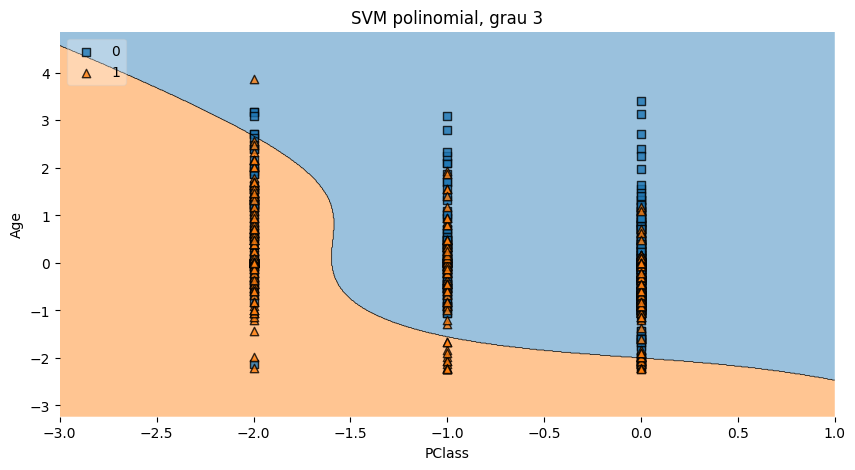

In [21]:
#polinomial grau 2
titulo = "SVM polinomial, grau 3"
svm = SVC(kernel = 'poly', degree=3)
svm.fit(Xtrain_red, ytrain)
decision_bound(Xtrain_red, ytrain, svm, titulo)

/home/deck/Mestrado/ContainerHomes/ComputacaoCienciaDados/dev/.venv/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but SVC was fitted with feature names
  warnings.warn(


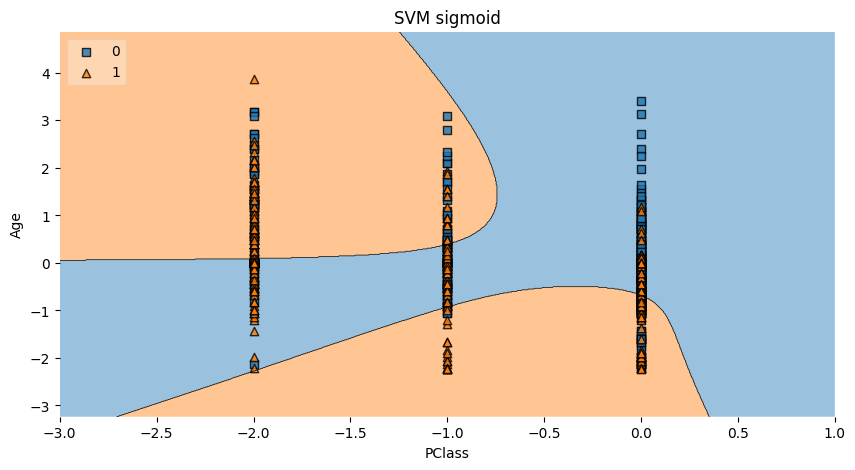

In [22]:
#polinomial grau 2
titulo = "SVM sigmoid"
svm = SVC(kernel = 'sigmoid')
svm.fit(Xtrain_red, ytrain)
decision_bound(Xtrain_red, ytrain, svm, titulo)


In [23]:
del(svm)

# SVM com diferentes valores de gama

O parâmetro gama, usado para os kernel gaussiano, polinomial e sigmóide, controla a distância a que são considerados os vetores de suporte:
  

*  valores mais elevados: apenas os pontos próximos da linha de separação são considerados;
*   valores mais baixos implica que são considerados pontos mais distantes.

Ou seja, este parâmetro pode ser interpretado como o inverso do raio de influência das amostras selecionadas pelo sistema como vetores de suporte.

Este parâmetro, que não é usado para o kernel linear,   pode assumir os valores `scale`, `auto`  ou  um valor real.  

* `gamma = scale`:  é usado o o valor $1/(n_{features} * X.var())$, onde $n_{features}$ é o número de atributos com que o modelo está a ser treinado e X.var() é a variância dos seus valores. É o valor por defeito

*  `gamma = auto`: é usado o valor  $1/n_{features}$.

SVM, kernel RBF , gama = auto


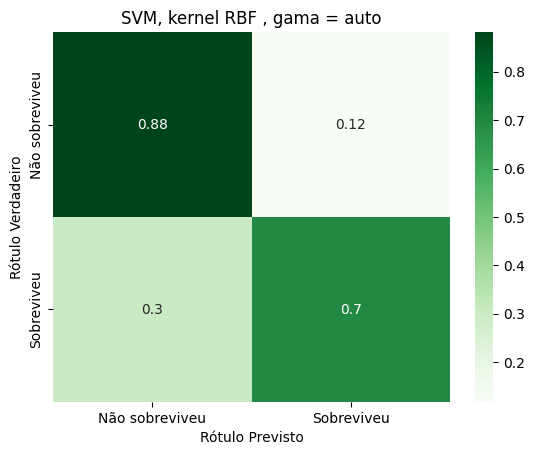

              precision    recall  f1-score   support

           0       0.82      0.88      0.85       110
           1       0.79      0.70      0.74        69

    accuracy                           0.81       179
   macro avg       0.80      0.79      0.79       179
weighted avg       0.81      0.81      0.81       179

SVM, kernel RBF , gama = scale


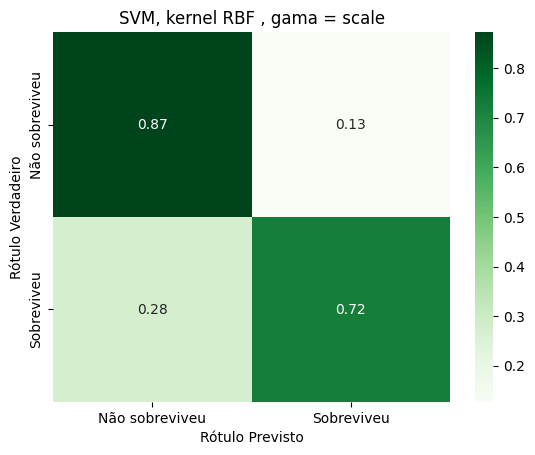

              precision    recall  f1-score   support

           0       0.83      0.87      0.85       110
           1       0.78      0.72      0.75        69

    accuracy                           0.82       179
   macro avg       0.81      0.80      0.80       179
weighted avg       0.81      0.82      0.81       179

SVM, kernel RBF , gama = 0.1


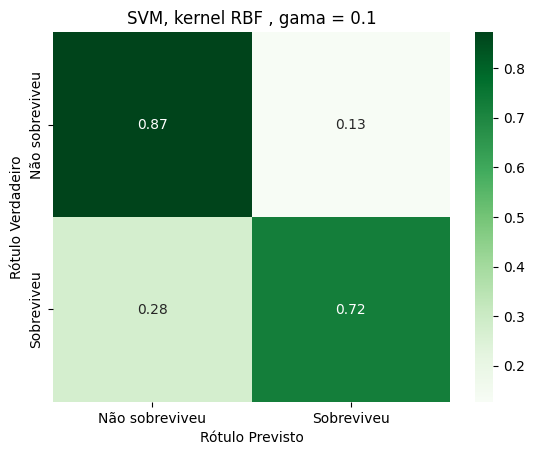

              precision    recall  f1-score   support

           0       0.83      0.87      0.85       110
           1       0.78      0.72      0.75        69

    accuracy                           0.82       179
   macro avg       0.81      0.80      0.80       179
weighted avg       0.81      0.82      0.81       179

SVM, kernel RBF , gama = 0.5


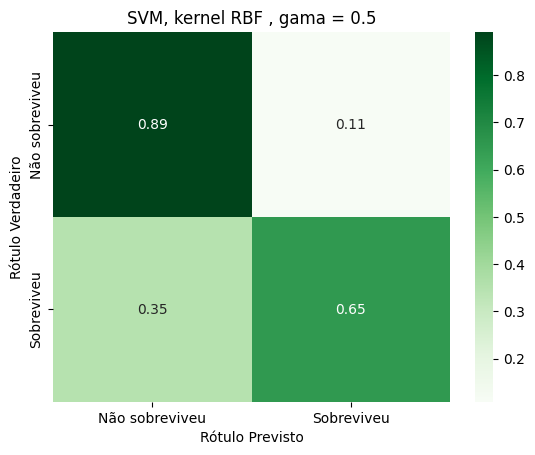

              precision    recall  f1-score   support

           0       0.80      0.89      0.84       110
           1       0.79      0.65      0.71        69

    accuracy                           0.80       179
   macro avg       0.80      0.77      0.78       179
weighted avg       0.80      0.80      0.79       179

SVM, kernel RBF , gama = 1


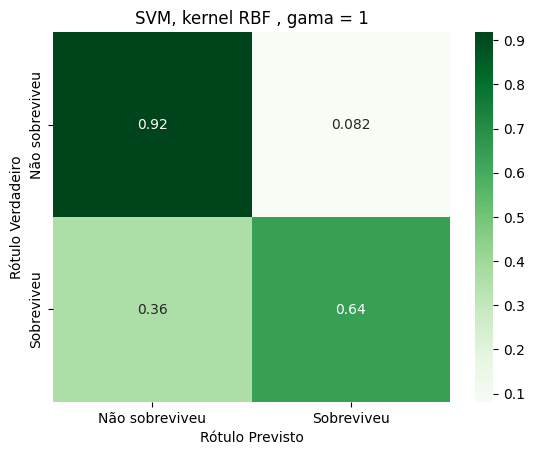

              precision    recall  f1-score   support

           0       0.80      0.92      0.86       110
           1       0.83      0.64      0.72        69

    accuracy                           0.81       179
   macro avg       0.82      0.78      0.79       179
weighted avg       0.81      0.81      0.80       179

SVM, kernel RBF , gama = 2


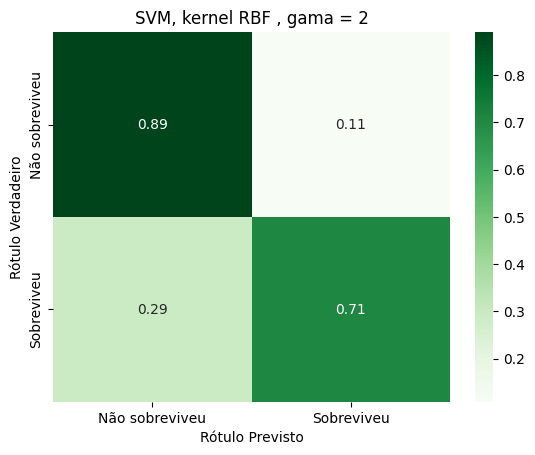

              precision    recall  f1-score   support

           0       0.83      0.89      0.86       110
           1       0.80      0.71      0.75        69

    accuracy                           0.82       179
   macro avg       0.82      0.80      0.81       179
weighted avg       0.82      0.82      0.82       179



,Train Accuracy,Test Accuracy,Test f1
"SVM, kernel RBF , gama = 2",0.89,0.82,0.81
"SVM, Kernel rbf",0.83,0.82,0.80
"SVM, kernel rbf",0.83,0.82,0.80
"SVM, kernel RBF , gama = scale",0.83,0.82,0.80
"SVM, kernel RBF , gama = 0.1",0.83,0.82,0.80
"SVM, kernel RBF , gama = auto",0.83,0.81,0.79
"SVM, kernel RBF , gama = 1",0.88,0.81,0.79
"SVM, kernel RBF , gama = 0.5",0.85,0.80,0.78
"SVM, kernel linear",0.79,0.79,0.77
"SVM, kernel poly, grau 2",0.82,0.75,0.71


In [24]:
gama = ['auto', 'scale', 0.1, 0.5,  1, 2, ]
for g in gama:
  nome = f"SVM, kernel RBF , gama = {g}"
  print(nome)
  svm_rbf = SVC(kernel = 'rbf', gamma=g)
  svm_rbf.fit(Xtrain_RScl, ytrain)
  ypred_test=svm_rbf.predict(Xtest_RScl)
  acc_score=svm_rbf.score(Xtrain_RScl, ytrain)
  model_evaluation(acc_score, ytest, ypred_test, nome)


#ordenar o df por melhor f1
performance = performance.sort_values(by="Test f1", ascending=False)
display(performance)

# SVM com diferentes valores de regularização

O parâmetro de regularização, C, controla a complexidade do modelo, com valores mais elevado resultando num modelo mais complexo.  
Por omissão, C tem valor 1.

In [37]:
del svm_rbf

SVM, kernel RBF , C = 0.1 g = 1


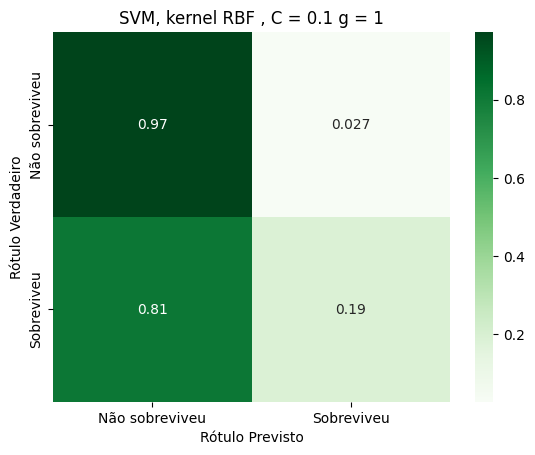

              precision    recall  f1-score   support

           0       0.66      0.97      0.78       110
           1       0.81      0.19      0.31        69

    accuracy                           0.67       179
   macro avg       0.73      0.58      0.54       179
weighted avg       0.72      0.67      0.60       179

SVM, kernel RBF , C = 1 g = 1


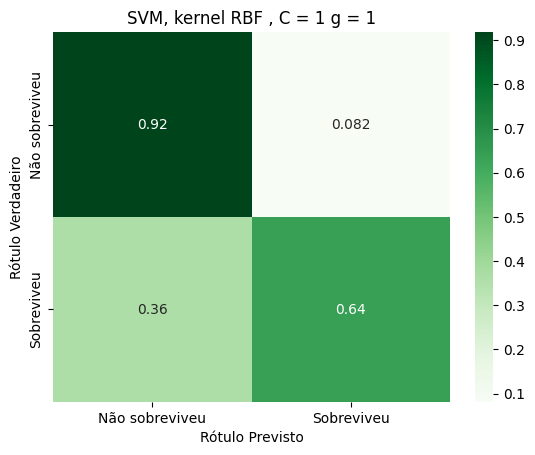

              precision    recall  f1-score   support

           0       0.80      0.92      0.86       110
           1       0.83      0.64      0.72        69

    accuracy                           0.81       179
   macro avg       0.82      0.78      0.79       179
weighted avg       0.81      0.81      0.80       179

SVM, kernel RBF , C = 5 g = 1


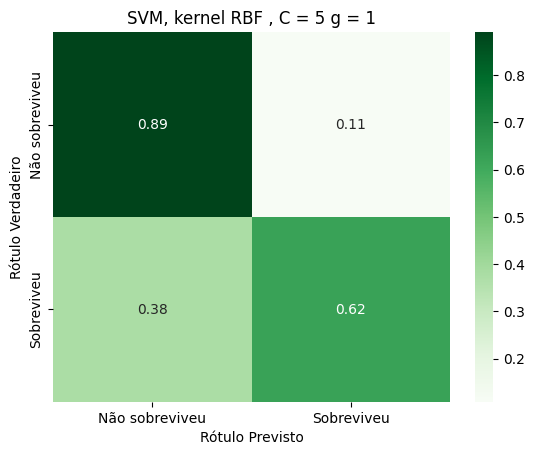

              precision    recall  f1-score   support

           0       0.79      0.89      0.84       110
           1       0.78      0.62      0.69        69

    accuracy                           0.79       179
   macro avg       0.79      0.76      0.77       179
weighted avg       0.79      0.79      0.78       179

SVM, kernel RBF , C = 10 g = 1


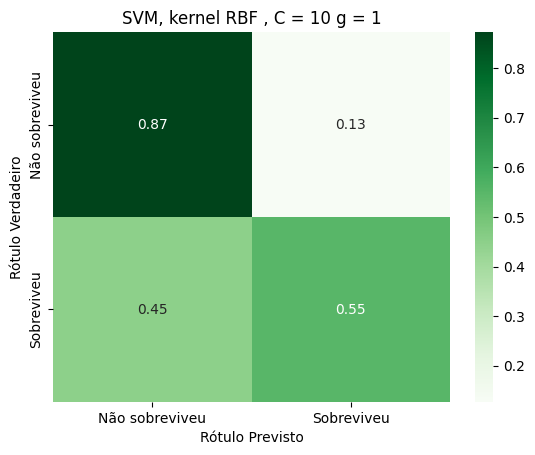

              precision    recall  f1-score   support

           0       0.76      0.87      0.81       110
           1       0.73      0.55      0.63        69

    accuracy                           0.75       179
   macro avg       0.74      0.71      0.72       179
weighted avg       0.75      0.75      0.74       179



,Train Accuracy,Test Accuracy,Test f1
"SVM, kernel RBF , gama = 2",0.89,0.82,0.81
"SVM, kernel rbf",0.83,0.82,0.80
"SVM, kernel RBF , gama = scale",0.83,0.82,0.80
"SVM, kernel RBF , gama = 0.1",0.83,0.82,0.80
"SVM, Kernel rbf",0.83,0.82,0.80
"SVM, kernel RBF , C = 1 g = 1",0.88,0.81,0.79
"SVM, kernel RBF , C = 1",0.88,0.81,0.79
"SVM, kernel RBF , gama = auto",0.83,0.81,0.79
"SVM, kernel RBF , gama = 1",0.88,0.81,0.79
"SVM, kernel RBF , gama = 0.5",0.85,0.80,0.78


In [39]:
C =  [0.1, 1, 5, 10]

for c in C:
    nome = f"SVM, kernel RBF , C = {c} g = 1"
    print(nome)
    svm_rbf = SVC(kernel = 'rbf', C=c, gamma=1)
    svm_rbf.fit(Xtrain_RScl, ytrain)
    ypred_test=svm_rbf.predict(Xtest_RScl)
    acc_score=svm_rbf.score(Xtrain_RScl, ytrain)
    model_evaluation(acc_score, ytest, ypred_test, nome)


#ordenar o df performance por melhor f1
performance = performance.sort_values(by="Test f1", ascending=False)
display(performance)


# Optimização com GridSearch

Frequentemente, o valor ótimo de um parâmetro está fortemente dependente do valor de outro(s) parâmetro(s). Por exemplo, nos modelos de SVM para classificação, isso acontece para os valores de C e de gama.

Nessas situações, os parâmetros devem ser optimizados em conjunto. 

A biblioteca `scikit learn` disponibiliza algumas funcionalidades para procurar o conjunto de parâmetros que optimiza a performance do modelo.

Uma delas é denominada `GridSearch`, que considera os parâmetros indicados e os respetivos intervalos de valores, testa exaustivamente todas as combinações possíveis e tem como saída a combinação de parâmetros que optimiza a métrica definida.  A funcionalidade `GridSearchCV` tem a característica de utilizar, adicionalmente, um procedimento de validação cruzada.  



Em seguida usa-se a funcionalidade `GridSearchCV` para procurar optimizar os hiperparâmetros do modelo de SVM. Os parâmetros e respetivos valores são indicados sob a forma de um dicionário, sendo os parâmetros as chaves, a que corresponde uma lista de valores possíveis.

In [41]:
#definir os parametros
parametros = {
    "C": [0.1, 1, 2, 5],
    "gamma": ['auto', 'scale', 1, 2]
}


In [44]:
#usar o GridSearch
from sklearn.model_selection import GridSearchCV

grid = GridSearchCV(SVC(), parametros, refit=True, verbose=2)
grid.fit(Xtrain_RScl, ytrain)

Fitting 5 folds for each of 16 candidates, totalling 80 fits
[CV] END ..................................C=0.1, gamma=auto; total time=   0.0s
[CV] END ..................................C=0.1, gamma=auto; total time=   0.0s
[CV] END ..................................C=0.1, gamma=auto; total time=   0.0s
[CV] END ..................................C=0.1, gamma=auto; total time=   0.0s
[CV] END ..................................C=0.1, gamma=auto; total time=   0.0s
[CV] END .................................C=0.1, gamma=scale; total time=   0.0s
[CV] END .................................C=0.1, gamma=scale; total time=   0.0s
[CV] END .................................C=0.1, gamma=scale; total time=   0.0s
[CV] END .................................C=0.1, gamma=scale; total time=   0.0s
[CV] END .................................C=0.1, gamma=scale; total time=   0.0s
[CV] END .....................................C=0.1, gamma=1; total time=   0.0s
[CV] END .....................................C=

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",SVC()
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'C': [0.1, 1, ...], 'gamma': ['auto', 'scale', ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",None
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the score is also displayed;- >3 : the fold and candidate p

In [45]:
#conhecer o melhor modelo encontrado

grid.best_estimator_

,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",2
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide `.",False
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


In [46]:
#conhecer os melhores parametros encontrados
grid.best_params_

{'C': 2, 'gamma': 'scale'}

In [47]:
#conhecer a melhor exatidão obtida
grid.best_score_

np.float64(0.8174135723431497)

Podemos agora usar este modelo optimizado para prever os resultados no conjunto de teste.

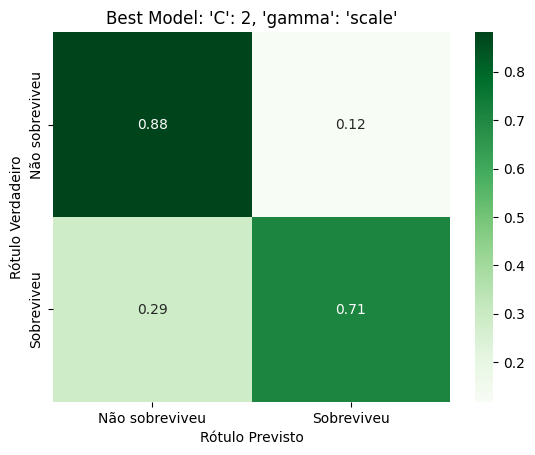

              precision    recall  f1-score   support

           0       0.83      0.88      0.85       110
           1       0.79      0.71      0.75        69

    accuracy                           0.82       179
   macro avg       0.81      0.80      0.80       179
weighted avg       0.81      0.82      0.81       179



In [50]:
predict_grid= grid.predict(Xtest_RScl)
model_evaluation(grid.best_score_, ytest, predict_grid, "Best Model: 'C': 2, 'gamma': 'scale'")

----